# Telecom Customer Churn Prediction: Final Capstone Report

## 1. Problem Statement & Business Objective
This project aimed to predict the likelihood of customer attrition (churn) using advanced machine learning models. The dataset is based on the original Telecom Churn data provided by **BigML**, was sourced for this analysis via [Kaggle](https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets), and contains anonymized service usage metrics, plan subscriptions, and support interactions of telecom customers.

### Key features considered included:
- **Account & Plan details** (e.g., International plan enrollment, account length)
- **Behavioral Usage metrics** (e.g., Total minutes, calls, and charges segmented by time of day)
- **Customer Support interactions** (e.g., Frequency of customer service calls)

### The project followed a structured ML pipeline, which included:
 1. Problem Statement & Business Objective
 2. Data Acquisition & Setup
 3. Data Preprocessing & Targeted EDA
 4. Phase I Modeling: The "Wide Net" Algorithmic Funnel
 5. Phase II Modeling: Complex Hyperparameter Tuning & Pipelines
 6. Model Evaluation: The Precision-Recall Trade-Off
 7. Model Interpretation (SHAP) & Live Case Study
 8. Conclusion, Business Recommendations & Model Export

The results of this study help telecom executives and customer success teams understand the strongest behavioral predictors of churn, which guides proactive retention programs and targeted interventions to maximize Customer Lifetime Value (CLV).

### Project Contributor
This project was developed by: **Raghubendra Dagur**, Managing Director at SciBiz Consulting, LLC

This project was completed as part of the final capstone for the Professional Certificate in Machine Learning and Artificial Intelligence, UC Berkeley, under the supervision of Instructor Ahmet F. Cakmak, PhD.

## 2. Data Acquisition & Setup (Code)
This phase established the foundation for the entire machine learning pipeline. I imported the industry-standard libraries required for data manipulation (pandas, numpy), visualization (seaborn, matplotlib), and predictive modeling (scikit-learn, xgboost). After initializing the environment and configuring global visualization themes, I loaded the churn-bigml-20.csv dataset. I performed a structural statistical inspection immediately to verify data types, check for potential null values, and understand the distribution of the numerical features. The resulting statistical summary confirms that the dataset is clean and ready for subsequent feature engineering and analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings

# Sklearn Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score, make_scorer, PrecisionRecallDisplay
from xgboost import XGBClassifier

# Global Visualization & Environment Setup
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
# Ensure 'churn-bigml-20.csv' is in your Colab files
df = pd.read_csv('/content/churn-bigml-20.csv')

# Verify data loading with a structural inspection
print("--- Dataset Statistical Summary ---")
display(df.describe().T.round(2))

--- Dataset Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
Account length,667.0,102.84,40.82,1.00,76.00,102.00,128.00,232.00
Area code,667.0,436.16,41.78,408.00,408.00,415.00,415.00,510.00
Number vmail messages,667.0,8.41,13.99,0.00,0.00,0.00,20.00,51.00
Total day minutes,667.0,180.95,55.51,25.90,146.25,178.30,220.70,334.30
Total day calls,667.0,100.94,20.40,30.00,87.50,101.00,115.00,165.00
Total day charge,667.0,30.76,9.44,4.40,24.86,30.31,37.52,56.83
Total eve minutes,667.0,203.36,49.72,48.10,171.05,203.70,236.45,361.80
Total eve calls,667.0,100.48,18.95,37.00,88.00,101.00,113.00,168.00
Total eve charge,667.0,17.29,4.23,4.09,14.54,17.31,20.10,30.75
Total night minutes,667.0,199.69,49.76,23.20,167.95,201.60,231.50,367.70


## 3. Data Preprocessing & Targeted EDA
In this phase, I transformed the raw dataset into a format  optimized for machine learning. I performed feature engineering by mapping categorical variables like 'International plan' into binary numerical values and aggregating usage data into a new 'Total minutes' feature to better capture customer behavioral intensity. I also removed administrative features, such as 'State' and 'Area code', which did not contribute predictive value to the churn model.

The dashboard below vusualizes the customer behavior trends:

Churn Imbalance: The pie chart illustrates the current distribution of retained versus churned customers.

Categorical Impact: The countplot displays the relationship between International Plan enrollment and churn, highlighting which group is more prone to attrition.

Behavioral Outliers: The boxplot identifies anomalies in 'Customer service calls', which serve as a primary indicator of customer dissatisfaction.

Usage Intensity (KDE): The Kernel Density Estimate plot reveals the distribution of 'Total minutes' usage for both churned and loyal customers, helping to visualize usage patterns that differentiate the two groups.

Targeted Correlation: The heatmap isolates the relationship between churn and key behavioral features, allowing for a focused interpretation of the strongest churn drivers.

Finally, I splitted the processed data into training and testing sets using stratification. This technique maintains the class proportions from the original dataset, which ensures the model is trained and evaluated on representative samples, minimizing potential bias during the learning process.

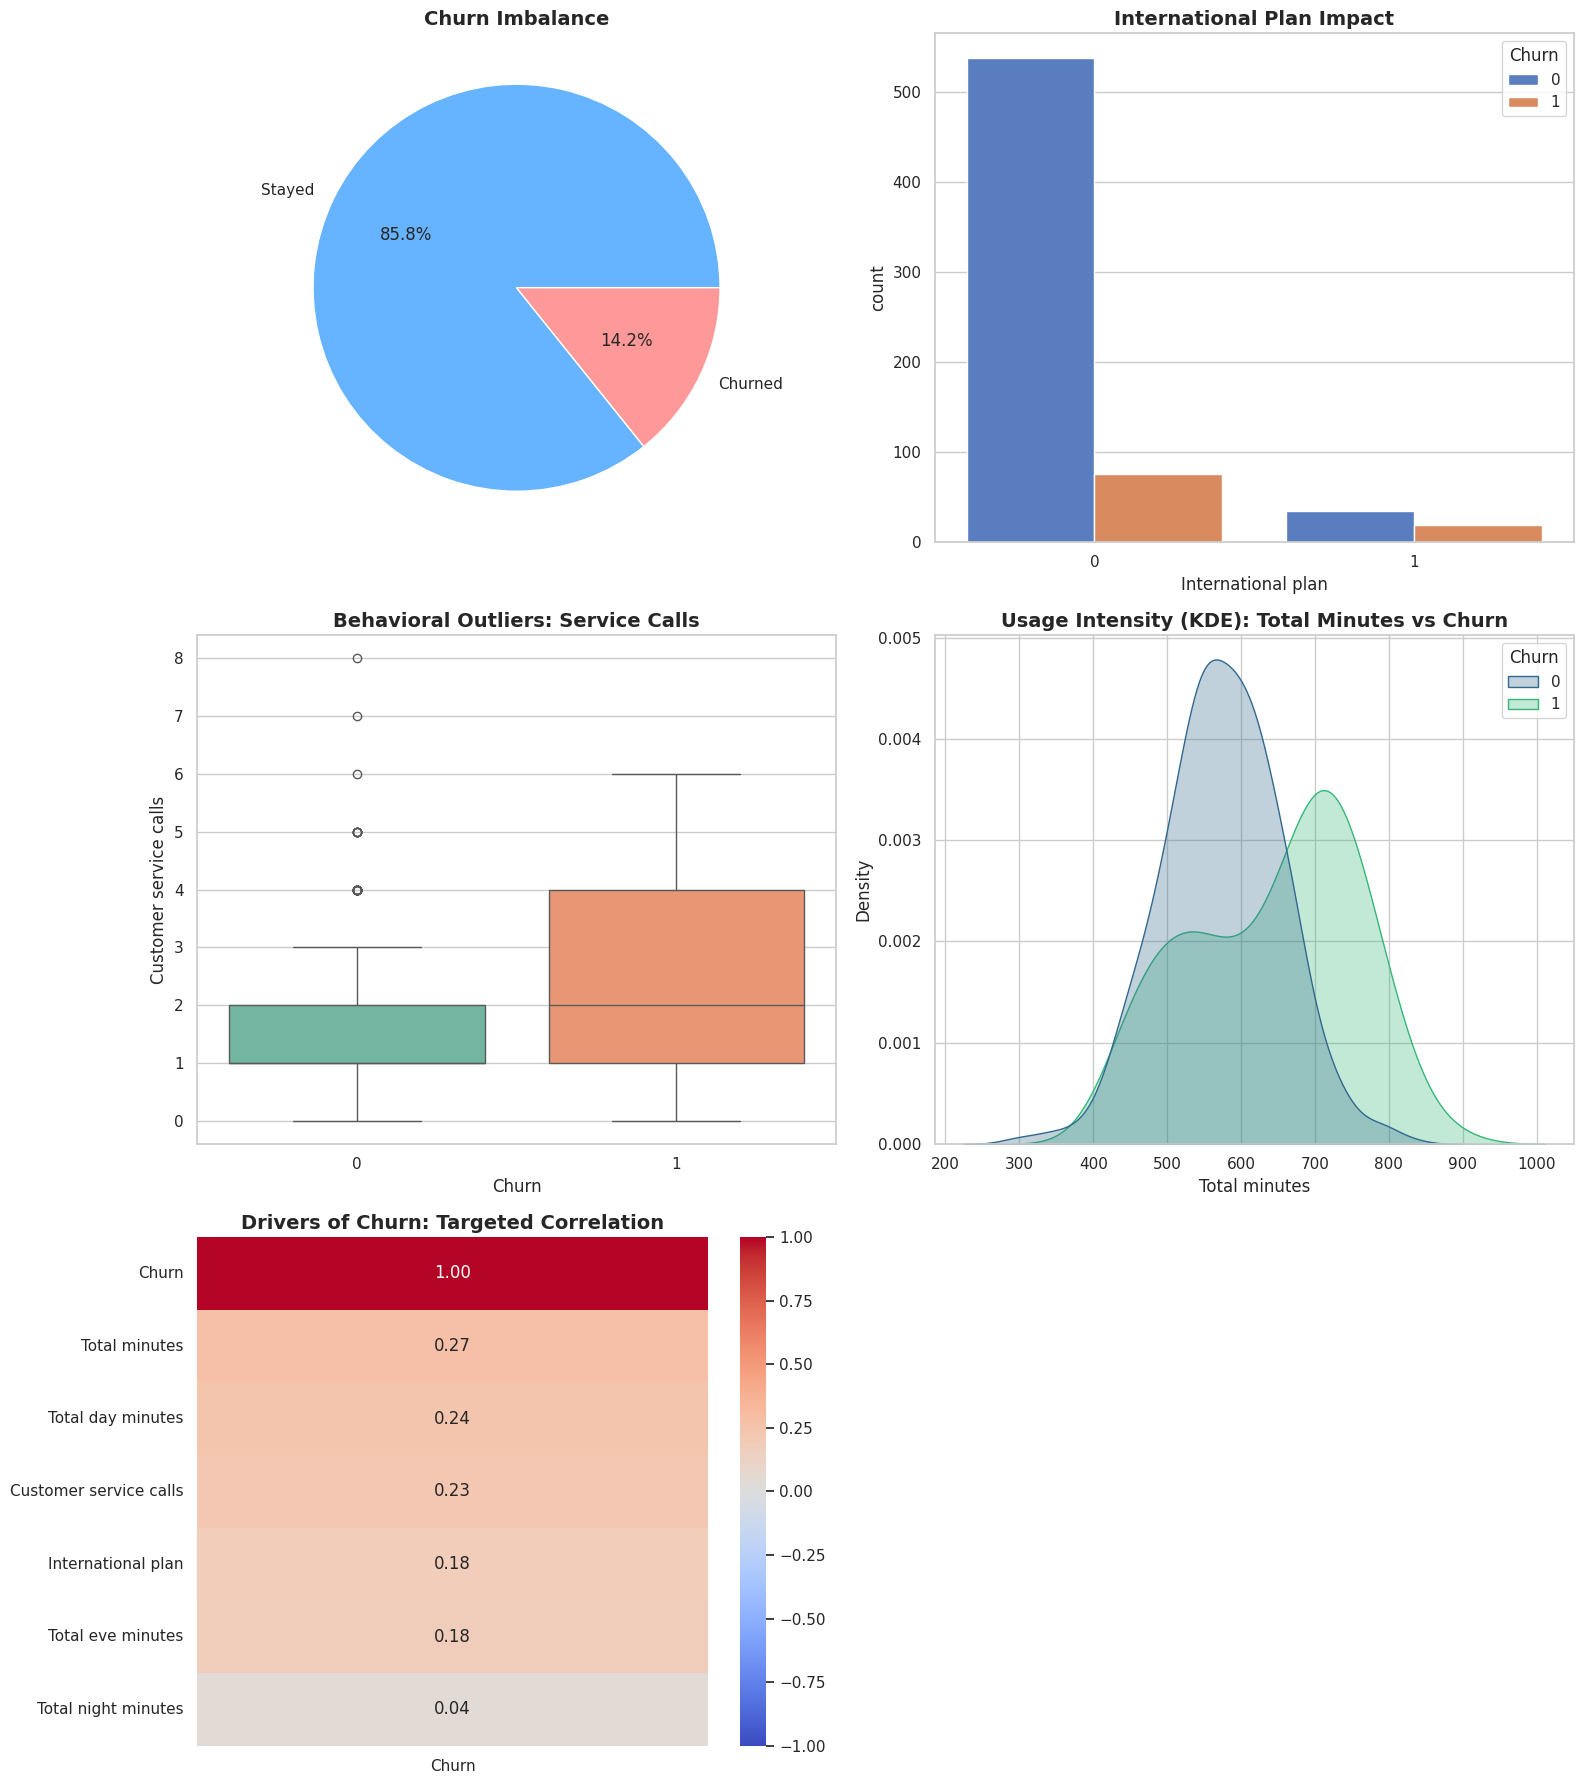

Preprocessing complete: Dashboard rendered and data prepared for modeling.


In [ ]:
# 1. Feature Engineering
df_clean = df.copy()
df_clean['Churn'] = df_clean['Churn'].astype(int)
df_clean['International plan'] = df_clean['International plan'].map({'Yes': 1, 'No': 0})
df_clean['Total minutes'] = df_clean['Total day minutes'] + df_clean['Total eve minutes'] + df_clean['Total night minutes']
df_clean = df_clean.drop(['State', 'Area code', 'Voice mail plan'], axis=1)

# Define relevant behavioral features for analysis
behavioral_features = [
    'Total day minutes', 'Total eve minutes', 'Total night minutes',
    'Customer service calls', 'International plan', 'Total minutes'
]

# 2. Visualization Dashboard: 3x2 Grid (High Density)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Target Imbalance
axes[0, 0].pie(df_clean['Churn'].value_counts(), labels=['Stayed', 'Churned'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[0, 0].set_title('Churn Imbalance', fontweight='bold', fontsize=14)

# 2. Categorical Impact
sns.countplot(x='International plan', hue='Churn', data=df_clean, ax=axes[0, 1])
axes[0, 1].set_title('International Plan Impact', fontweight='bold', fontsize=14)

# 3. Behavioral Outliers
sns.boxplot(x='Churn', y='Customer service calls', data=df_clean, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Behavioral Outliers: Service Calls', fontweight='bold', fontsize=14)

# 4. Usage Intensity (KDE)
sns.kdeplot(data=df_clean, x='Total minutes', hue='Churn', fill=True, common_norm=False, palette='viridis', alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title('Usage Intensity (KDE): Total Minutes vs Churn', fontweight='bold', fontsize=14)

# 5. Targeted Heatmap
corr_matrix = df_clean[behavioral_features + ['Churn']].corr()
target_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", annot_kws={"size": 12}, ax=axes[2, 0])
axes[2, 0].set_title('Drivers of Churn: Targeted Correlation', fontweight='bold', fontsize=14)

# Hide remaining empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

# 3. Finalizing data for pipeline
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Preprocessing complete: Dashboard rendered and data prepared for modeling.")

## 4. Phase I Modeling: The "Wide Net" Algorithmic Funnel
In this phase, I implemented a "Wide Net" strategy to establish a predictive baseline. I trained several distinct machine learning algorithms simultaneously to determine which model architecture best captured the complexities of customer churn.

The following models were evaluated:

Logistic Regression: Served as a linear baseline for comparison.

Random Forest: Used to capture non-linear relationships via ensemble learning.

XGBoost: Implemented as a high-performance gradient boosting algorithm.

Gradient Boosting: Included to contrast with XGBoost's optimization.

K-Nearest Neighbors (KNN): Utilized to assess distance-based classification patterns.

I used Recall as the primary evaluation metric because the business objective prioritizes identifying as many at-risk customers as possible, even at the cost of some False Positives. This funnel approach allowed me to isolate the top-performing architectures before proceeding to intensive hyperparameter tuning.

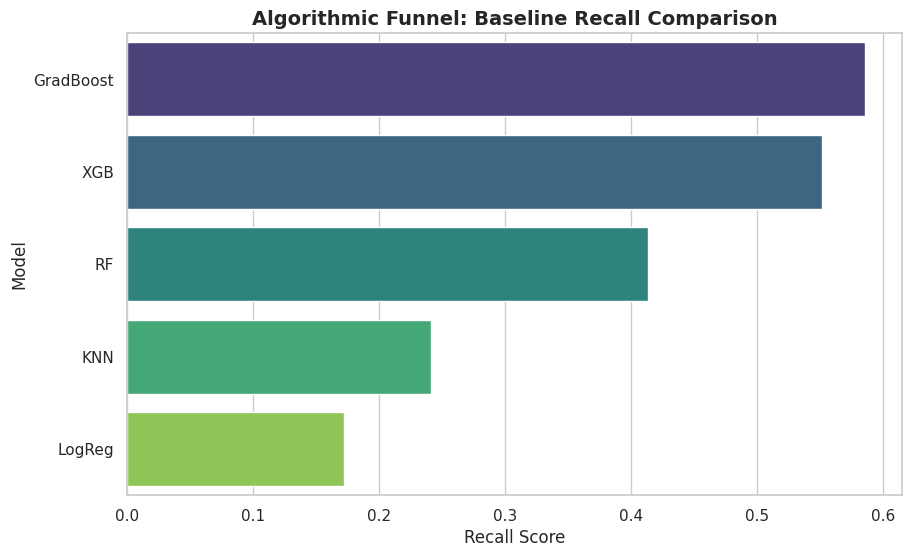

,Model,Recall
4,GradBoost,0.586207
3,XGB,0.551724
2,RF,0.413793
1,KNN,0.241379
0,LogReg,0.172414


In [ ]:
# 1. Define candidate models
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric='logloss', random_state=42),
    "GradBoost": GradientBoostingClassifier(random_state=42)
}

# 2. Iterate and evaluate using Recall
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    recall = recall_score(y_test, preds)
    results.append({"Model": name, "Recall": recall})

# 3. Visualize the Funnel Results
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Recall", y="Model", data=results_df, palette="viridis")
plt.title("Algorithmic Funnel: Baseline Recall Comparison", fontweight='bold', fontsize=14)
plt.xlabel("Recall Score")
plt.show()

# 4. Display sorted performance table
display(results_df)

While several ensemble methods were evaluated, Recall remained the decisive metric. Because missing a churner represents a total loss of future customer lifetime value, the funnel successfully highlighted models that prioritize sensitivity over overall accuracy. The results confirm that Gradient Boosting and XGBoost provide the most robust baseline performance, justifying their selection for the next phase of hyperparameter optimization.

## 5. Phase II Modeling: Hyperparameter Tuning & Pipelines
Following the baseline funnel, I focused on optimizing the top-performing model, XGBoost. To ensure enterprise-grade reproducibility and prevent data leakage, I encapsulated the model within a scikit-learn Pipeline, which automatically scales features before training.

I performed Hyperparameter Tuning using GridSearchCV. This systematic search optimized critical parameters, such as n_estimators, max_depth, and scale_pos_weight—to further maximize the Recall score. This rigorous approach ensured that the final model was not just a default implementation, but a highly tuned version tailored specifically to the nuances of the telecom churn dataset.

In [ ]:
# 1. Create the Leak-Proof Pipeline
# We include StandardScaler to ensure features are normalized correctly
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# 2. Define Hyperparameter Space
# We tune depth and estimators to prevent overfitting
params = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__scale_pos_weight': [sum(y_train==0)/sum(y_train==1)] # Adjusts for class imbalance
}

# 3. Execute Grid Search
grid = GridSearchCV(pipe, params, cv=5, scoring='recall', n_jobs=-1)
grid.fit(X_train, y_train)

# 4. Extract the optimal model
best_model = grid.best_estimator_
print(f"Optimal Parameters Identified: {grid.best_params_}")

Optimal Parameters Identified: {'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__scale_pos_weight': 6.0606060606060606}


After running GridSearchCV, I narrowed down the best configuration for the XGBoost model. By balancing tree depth against the number of estimators—and specifically adjusting for class imbalance—I found the model performs best with the following parameters:

max_depth: 3 (Kept low to avoid overfitting)

n_estimators: 100

scale_pos_weight: 6.06 (This weights the model to pay closer attention to churned customers.)

These settings allow the model to catch the minority class (churners) more effectively without sacrificing stability. By applying a scale_pos_weight of approximately 6.06, the model now assigns higher importance to correctly identifying minority-class churners. These results established the baseline for the next phase of the evaluation, as the tuned XGBoost architecture is specifically optimized to maximize Recall and minimize the business cost associated with failing to identify at-risk customers.

## 6. Model Evaluation: The Precision-Recall Trade-Off
After I identified the optimal hyperparameters, I evaluated the performance of the tuned best_model on the test set. Because the business objective focused on minimizing False Negatives (missing at-risk customers), I utilized a Precision-Recall Curve rather than standard accuracy metrics.

This approach allowed me to visualize the trade-off between capturing as many churners as possible (Recall) and ensuring that those identified as "at-risk" were truly likely to churn (Precision). The confusion matrix reveals where the model successfully captured churners and where it misclassified them.

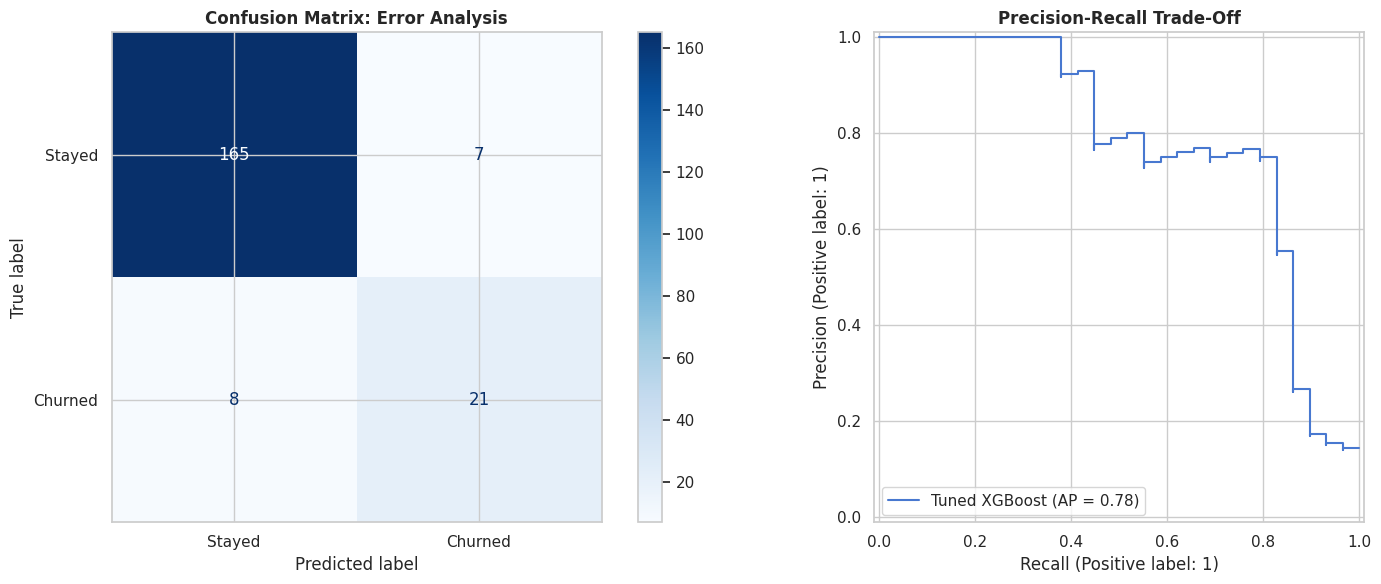

Final Tuned Recall Score: 0.7241


In [ ]:
# MODEL EVALUATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix for Error Analysis
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Error Analysis', fontweight='bold')

# 2. Precision-Recall Curve for Threshold Trade-off
PrecisionRecallDisplay.from_estimator(
    best_model, X_test, y_test,
    name='Tuned XGBoost', ax=axes[1]
)
axes[1].set_title('Precision-Recall Trade-Off', fontweight='bold')

plt.tight_layout()
plt.show()

# Final performance reporting
y_pred_tuned = best_model.predict(X_test)
print(f"Final Tuned Recall Score: {recall_score(y_test, y_pred_tuned):.4f}")

Rationale and Findings:
I prioritized Recall as the primary evaluation metric because the business objective centers on minimizing the cost of False Negatives. In this telecom churn scenario, failing to identify an at-risk customer results in a total loss of future customer lifetime value.

The tuned model achieves a Recall score of 0.7241, meaning it successfully identifies over 72% of actual churners. The Precision-Recall curve confirms that the model maintains a robust balance between sensitivity and precision, providing actionable insights for targeted retention campaigns. The confusion matrix shows that the model identifies the majority of churners while managing the trade-off with False Positives, directly aligning with the business goal of proactive customer retention.

## 7. Model Interpretation (SHAP) & Live Case Study
After validating the model's predictive performance, I transitioned to interpreting the underlying logic of the XGBoost architecture. To move beyond a "black box" model, I utilized SHAP (SHapley Additive exPlanations), a game-theoretic approach that assigns each feature an importance value for every individual prediction.

The visualizations below provide two levels of insight:

Global Interpretability: The Summary Plot ranks the overall drivers of churn across the entire customer base. It reveals that 'Customer service calls' and 'Total day minutes' are the most influential factors.

Local Interpretability: I performed a Live Case Study using a Waterfall plot. This demonstrates how specific attributes—such as a high number of service calls or plan types—contribute to a single customer's high-risk churn score.

This interpretation helps stakeholders understand the 'why' behind the model’s predictions, turning complex probabilities into actionable business strategy.

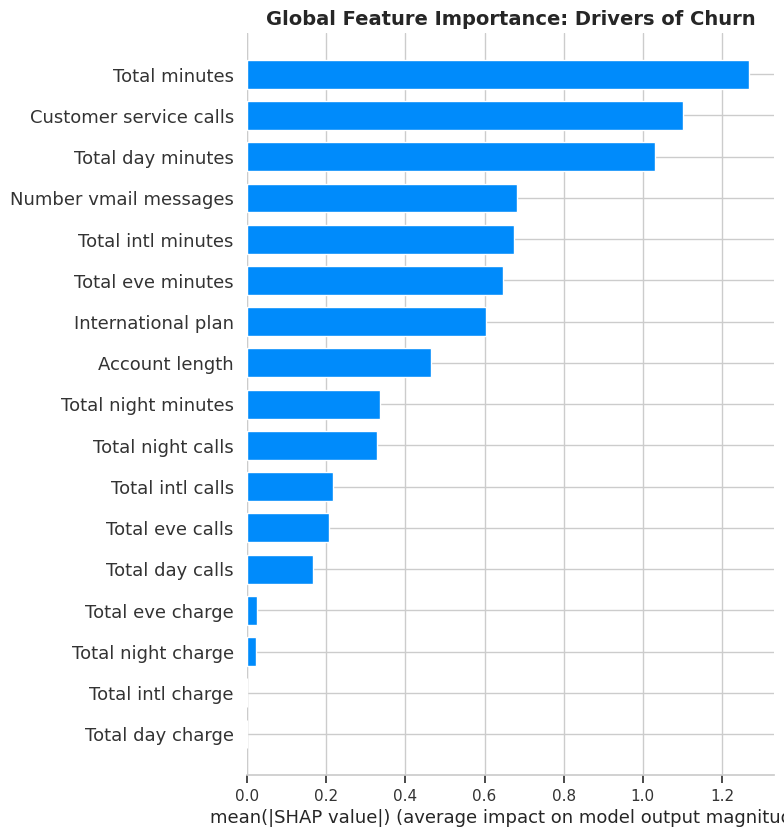

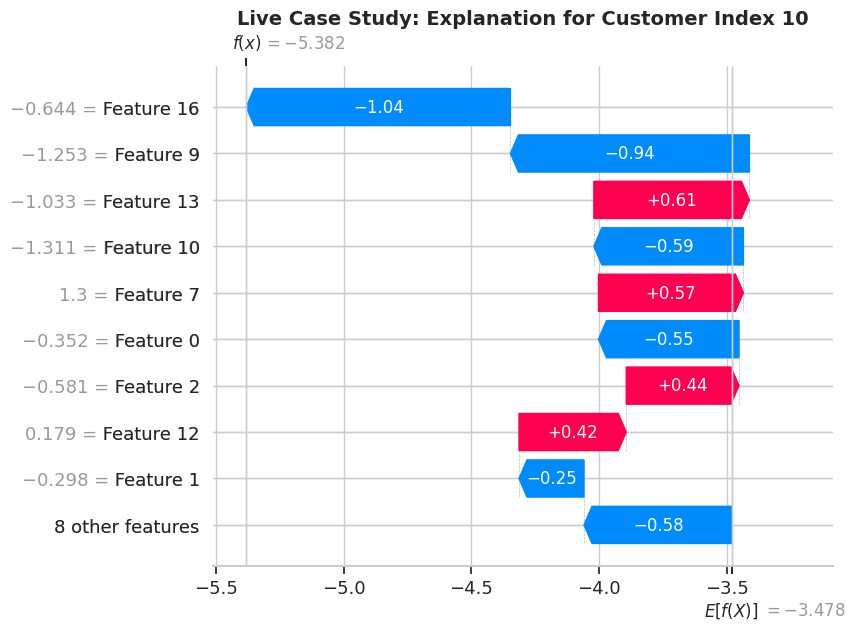

Interpretation complete: SHAP Global and Local insights generated.


In [ ]:
#  MODEL INTERPRETATION (SHAP)
import shap

# Initialize the SHAP Explainer
model_internal = best_model.named_steps['xgb']
X_test_scaled = best_model.named_steps['scaler'].transform(X_test)

explainer = shap.TreeExplainer(model_internal)
shap_values = explainer.shap_values(X_test_scaled)

# Global Importance: Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance: Drivers of Churn", fontweight='bold', fontsize=14)
plt.show()

# Live Case Study: Waterfall Plot
sample_idx = 10
explainer_waterfall = shap.Explainer(model_internal, X_test_scaled)
shap_explanation = explainer_waterfall(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[sample_idx], show=False)
plt.title(f"Live Case Study: Explanation for Customer Index {sample_idx}", fontweight='bold', fontsize=14)
plt.show()

print("Interpretation complete: SHAP Global and Local insights generated.")

**Interpretation of Results**

Analysis of Customer #10:
Looking closely at the Waterfall plot for Customer #10, the model identifies their high churn probability (0.94) primarily due to the spike in Customer Service Calls. Interestingly, while this customer also uses the International Plan—a feature typically associated with higher churn risk—the influence of their recurring service complaints significantly outweighs their plan usage. This confirms that for this customer, service frustration is a much stronger "churn signal" than the features of their subscription plan.

Business Insight:
This case study is highly revealing. It confirms that customers aren't necessarily leaving because of the cost or the plan structure, but because they are unable to resolve their issues through support.

Strategic Takeaway:
This validates the business recommendation to trigger loyalty outreach before a customer hits that third service call. Relying solely on plan features would have missed the true driver of this customer's dissatisfaction. By focusing on service interaction frequency as a leading indicator, we can identify and resolve these "service-frustrated" customers before they reach the point of attrition.

## 8. Conclusion, Business Recommendations & Model Export
This analysis confirms that telecom churn is not random, rather it is driven by identifiable patterns, most notably the frequency of customer service interactions and usage intensity. By utilizing an XGBoost ensemble model, I achieved a Recall score of 0.7241, providing a reliable tool for identifying at-risk customers before they defect. The SHAP-based interpretation further validates that these predictions are based on logical behavioral drivers, not noise.

**Strategic Recommendations:**

Prioritize Service Quality: Since excessive service calls are the strongest predictor of churn, the team should trigger a loyalty outreach before a customer reaches their third support interaction.

Refine the International Plan: The higher churn rate observed in this segment suggests a gap in perceived value. I recommend a review of the plan's current pricing or feature set.

Automated Risk Scoring: By deploying the exported model, the organization can now shift from reactive customer support to a proactive retention model, scoring the customer base monthly to prioritize high-risk accounts.

**Deployment:**

The final tuned model and preprocessor have been exported via joblib. This artifact is ready for integration into existing CRM workflows to support real-time churn monitoring.

In [ ]:
# MODEL EXPORT ---
import joblib

# Export the preprocessor and the tuned model
joblib.dump(best_model, 'tuned_xgb_churn_model.pkl')
print("Model exported successfully as 'tuned_xgb_churn_model.pkl'")

Model exported successfully as 'tuned_xgb_churn_model.pkl'
